In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import re

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

2026-06-17 00:29:01.784182: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
NUM_POINTS = 50

## Read Data

In [3]:
def load_data(folder):
    data = []
    for root, subdirs, files in os.walk(folder):
        if '.ipynb_checkpoints' in root:
            continue
        if len(files) > 0:
            for f in tqdm(files):
                if not f.endswith('.xml'):
                    continue
                xml_root = ET.parse(os.path.join(root, f)).getroot()
                fname = f.split('.')[0]
                label = re.sub(r'\d+', '', fname)
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                points = np.array(points, dtype=float)
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                resampled = resample(points, NUM_POINTS)
                data.append((label, resampled))
    return data

In [4]:
train_data = load_data('datasets/logs')
test_data = load_data('datasets/logs_custom')

print(f'Train samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Train samples: 5280
Test samples: 160


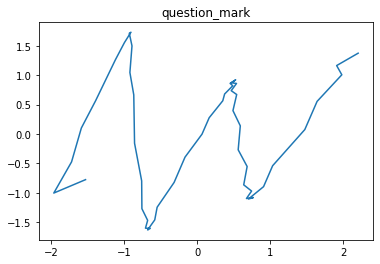

In [5]:
sample = random.choice(test_data)

label = sample[0]
sequence = sample[1]

plt.plot(sequence.T[0], sequence.T[1] * -1)
plt.title(label)
plt.show()

## Prepare Data

In [6]:
# Prepare training and test data

train_labels = [sample[0] for sample in train_data]
test_labels = [sample[0] for sample in test_data]

print("Train labels:", set(train_labels))
print("Test labels:", set(test_labels))

# Encode labels
encoder = LabelEncoder()
encoder.fit(train_labels)

y_train = to_categorical(encoder.transform(train_labels))
y_test = to_categorical(encoder.transform(test_labels))

# Get point sequences
X_train = np.array([sample[1] for sample in train_data])
X_test = np.array([sample[1] for sample in test_data])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Train labels: {'v', 'star', 'caret', 'left_curly_brace', 'question_mark', 'rectangle', 'arrow', 'x', 'triangle', 'delete_mark', 'circle', 'check', 'right_sq_bracket', 'pigtail', 'left_sq_bracket', 'right_curly_brace'}
Test labels: {'star', 'v', 'caret', 'left_curly_brace', 'question_mark', 'rectangle', 'arrow', 'x', 'triangle', 'delete_mark', 'circle', 'check', 'right_sq_bracket', 'pigtail', 'left_sq_bracket', 'right_curly_brace'}
X_train: (5280, 50, 2)
X_test: (160, 50, 2)
y_train: (5280, 16)
y_test: (160, 16)


## Define and Train Model 

In [31]:
# Define the model
model = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

# old syntax
#model.add(LSTM(64, input_shape=(NUM_POINTS, 2)))

# new syntax
model.add(Input((NUM_POINTS, 2)))
model.add(LSTM(64))

# add dense layer to do machine learning magic
model.add(Dense(32, activation='relu'))

# here, you can add more layers and maybe a dropout for better performance

# softmax layer for classification
model.add(Dense(y_train.shape[1], activation="softmax"))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

In [33]:
model.summary()

LSTM 16
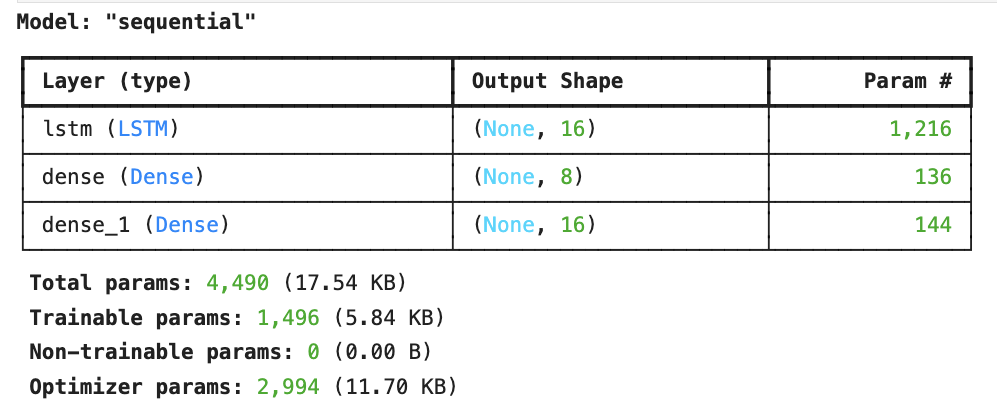

LSTM 32
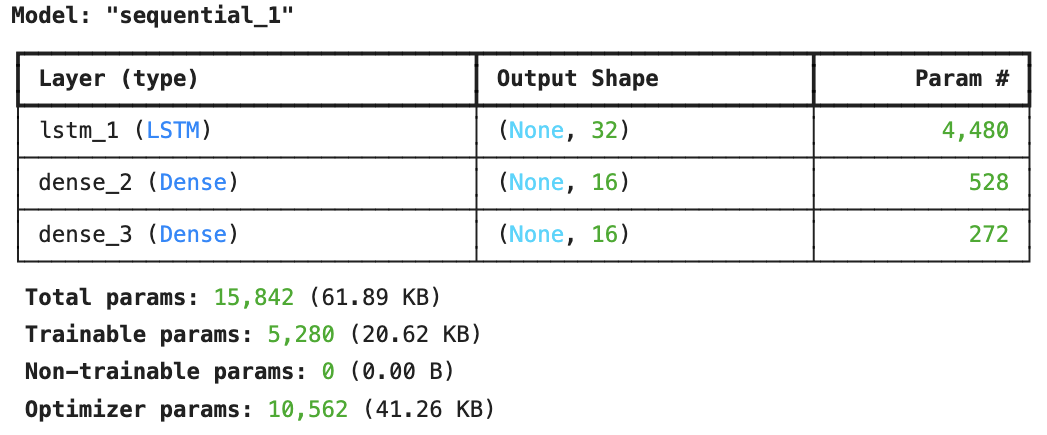

LSTM 64
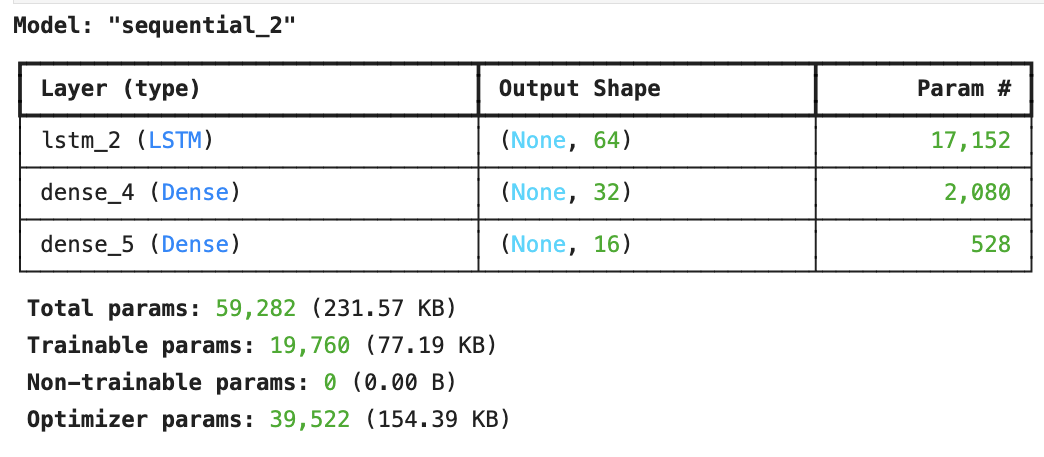

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

LSTM 16
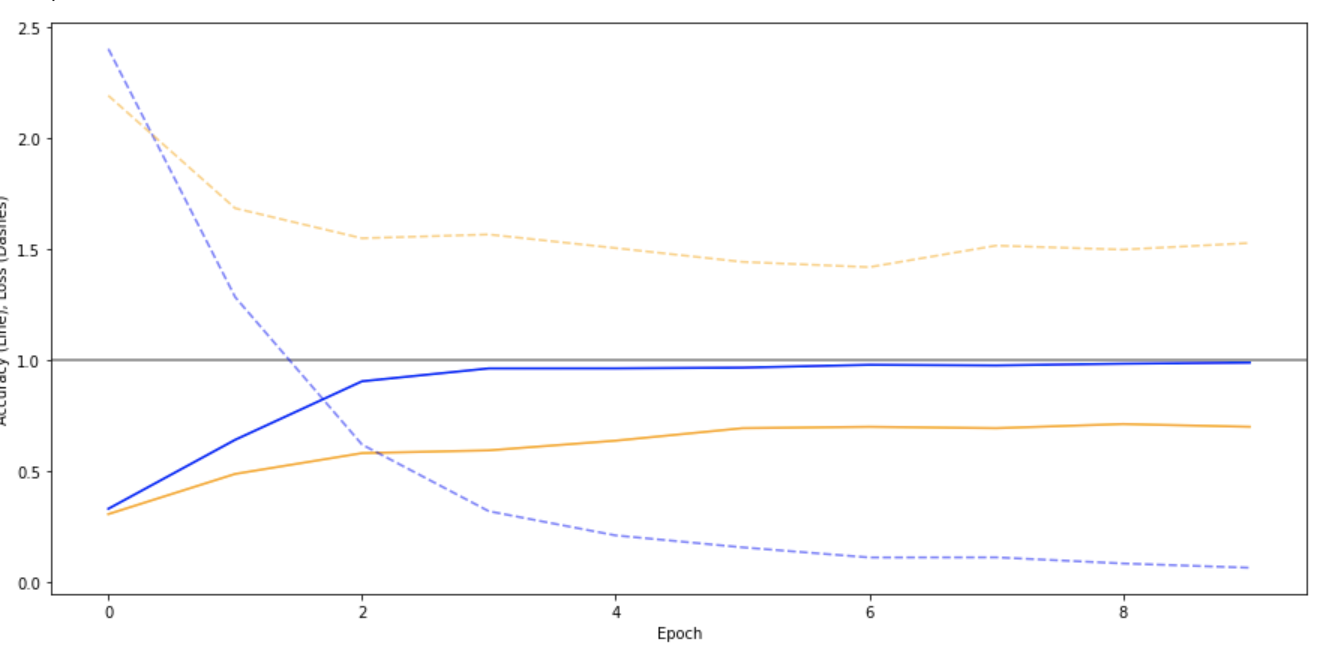

The LSTM-16 model converges quickly within the first three epochs. Training accuracy reaches almost 100%, while validation accuracy stabilizes around 70%. Validation loss decreases initially but remains relatively high and starts to fluctuate after epoch 5, indicating mild overfitting. The model provides a good trade-off between accuracy and computational complexity.

LSTM 32
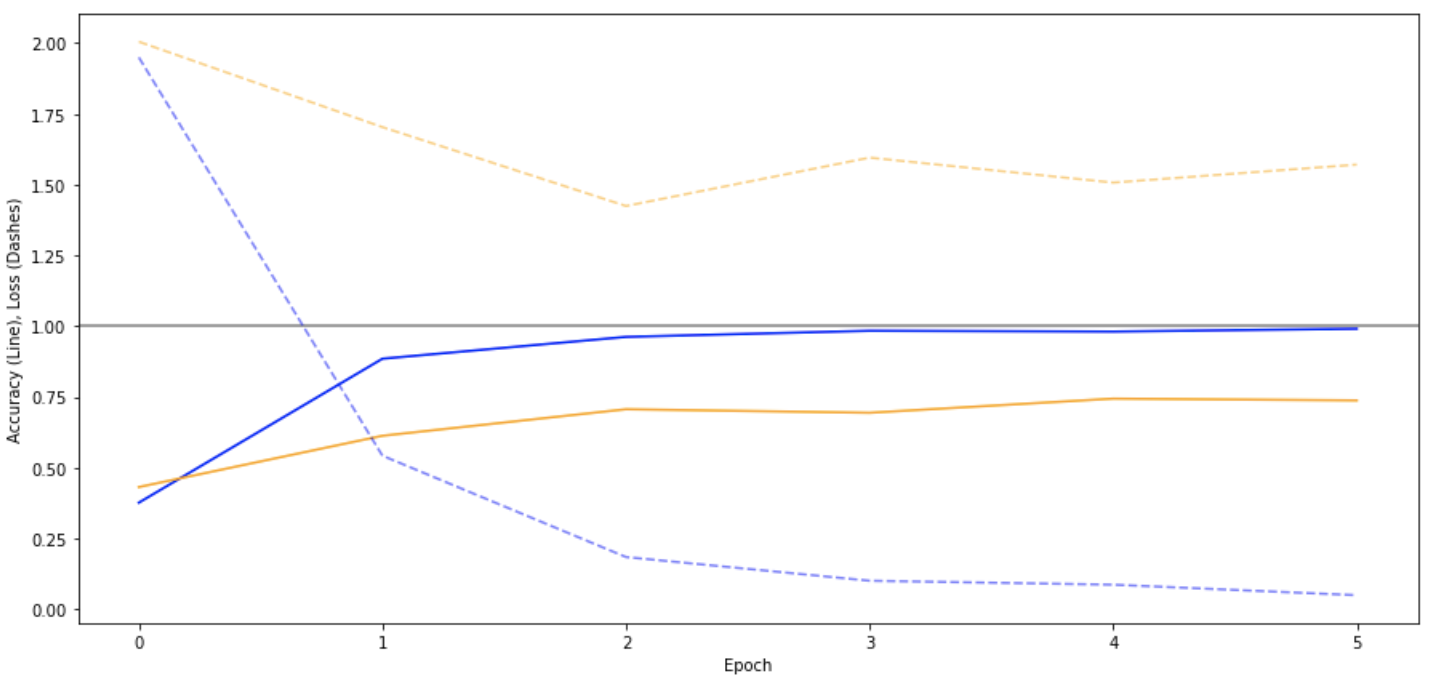

The LSTM-32 model learns faster than LSTM-16 and achieves similar training accuracy. Validation accuracy improves slightly to around 75%, while validation loss remains more stable during training. Compared to LSTM-16, the larger model offers better generalization with only a moderate increase in model complexity.

LSTM 64:
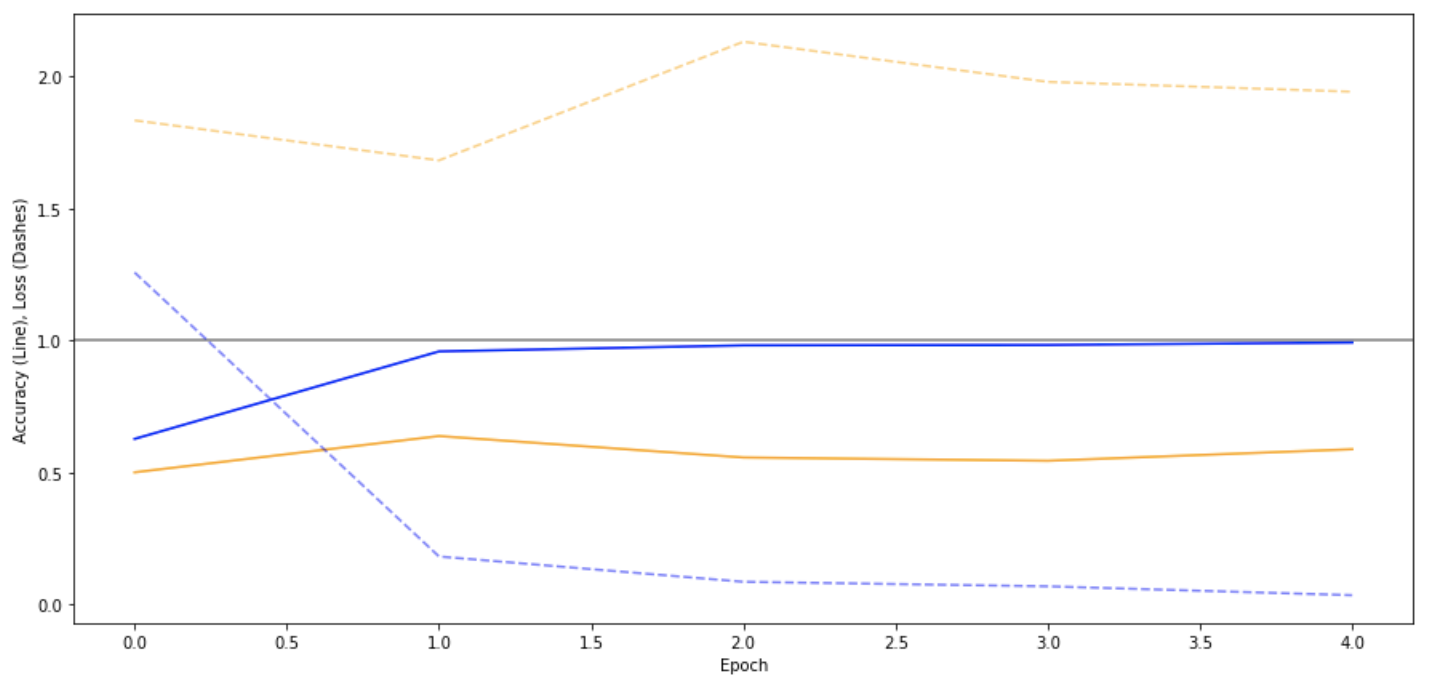

The LSTM-64 model reaches nearly perfect training accuracy after only two epochs. However, validation accuracy decreases to around 60%, while validation loss increases significantly. This behavior indicates strong overfitting caused by the larger number of trainable parameters relative to the dataset size.

## Predict

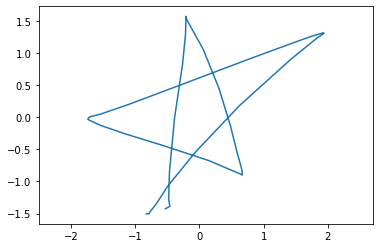

true label: star
prediction: star
confidence: 0.83736324


In [45]:
sample = random.choice(test_data)

label = sample[0]
sequence = sample[1]

plt.plot(sequence[:, 0], -sequence[:, 1])
plt.axis("equal")
plt.show()

prediction = model.predict(np.array([sequence]), verbose=0)

prediction_label_encoded = np.argmax(prediction)
prediction_label = encoder.inverse_transform(
    [prediction_label_encoded]
)[0]

print("true label:", label)
print("prediction:", prediction_label)
print("confidence:", prediction.max())

In [ ]:
# Make predictions for all the samples in test data

# y_pred = model.predict(X_test)
import time

start = time.time()

y_pred = model.predict(X_test)

prediction_time = time.time() - start

print(f"Prediction time: {prediction_time:.4f} seconds")

# convert probabilities -> class indices
y_pred_classes = np.argmax(y_pred, axis=1)

# convert one-hot labels -> class indices
y_true_classes = np.argmax(y_test, axis=1)

Prediction time:
LSTM 16: 0.3078 seconds,
LSTM 32: 0.2778 seconds,
LSTM 64: 0.2986 seconds.

In [ ]:
# Print accuracy of model on test data
print(f"Test Accuracy: {(y_pred_classes == y_true_classes).mean():.4f}")

Test Accuracy: 
LSTM 16: 0.7000,
LSTM 32: 0.7375,
LSTM 64: 0.5875.

In [ ]:
# Show confusion matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation="vertical"
)

plt.tight_layout()
plt.show()

LSTM 16
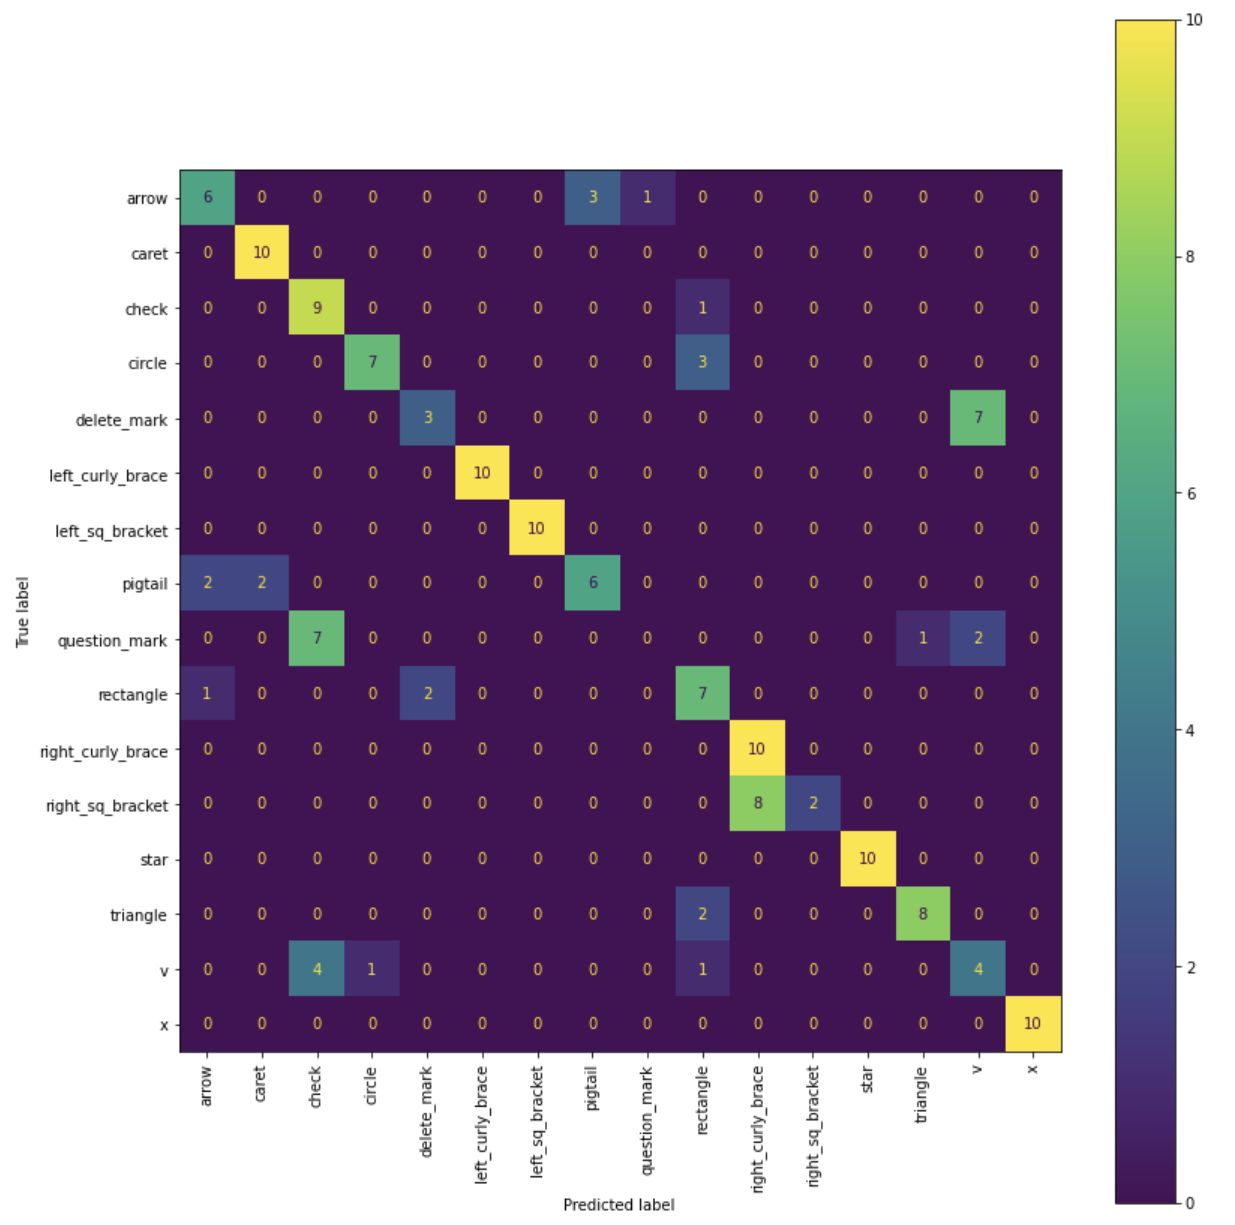

The confusion matrix of the LSTM-16 model shows strong performance for gestures with distinctive shapes, such as caret, left_curly_brace, left_sq_bracket, right_curly_brace, star, and x, which achieve perfect classification accuracy.

However, the model struggles with visually similar gestures. The most notable confusion occurs between delete_mark and v, question_mark and check, as well as right_sq_bracket and right_curly_brace. These results suggest that the limited model capacity is insufficient to fully capture subtle differences between similar stroke patterns.

LSTM 32
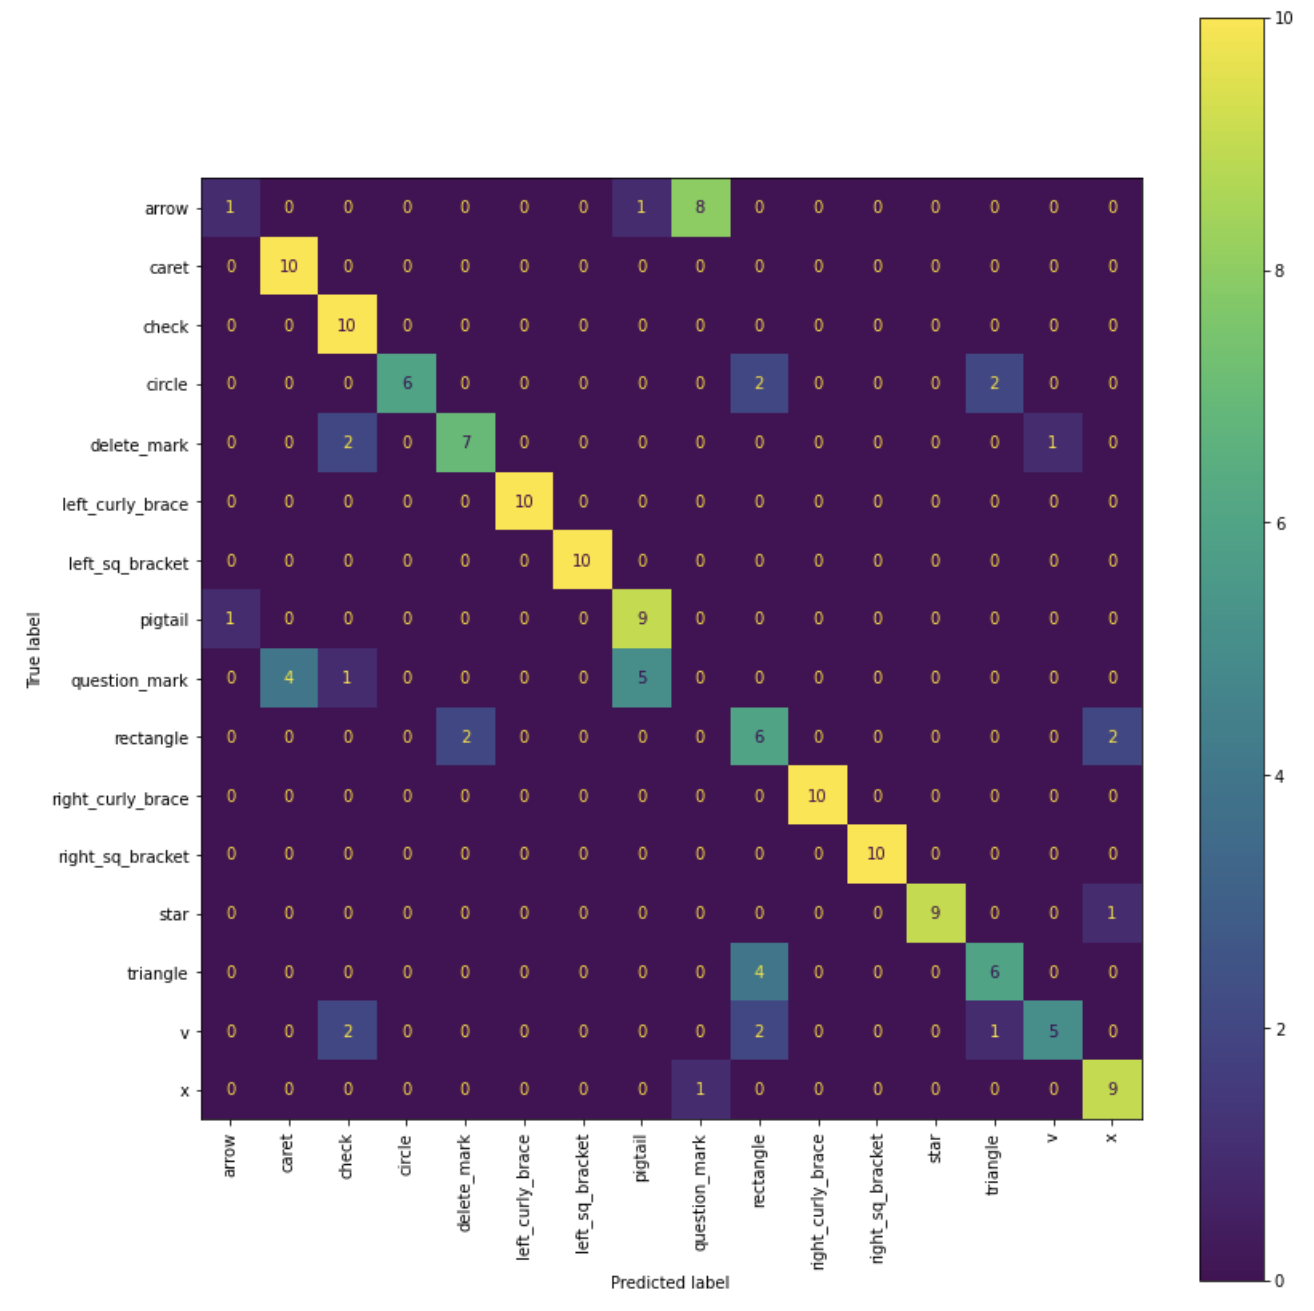

The LSTM-32 confusion matrix demonstrates improved classification performance compared to LSTM-16. Several gesture classes, including check, caret, left_curly_brace, left_sq_bracket, right_curly_brace, and right_sq_bracket, achieve perfect recognition.

Misclassifications are reduced for most categories, although some ambiguities remain between question_mark and pigtail, triangle and rectangle, as well as arrow and question_mark. Overall, the predictions are more concentrated along the diagonal, indicating better generalization and class separation.

LSTM 64
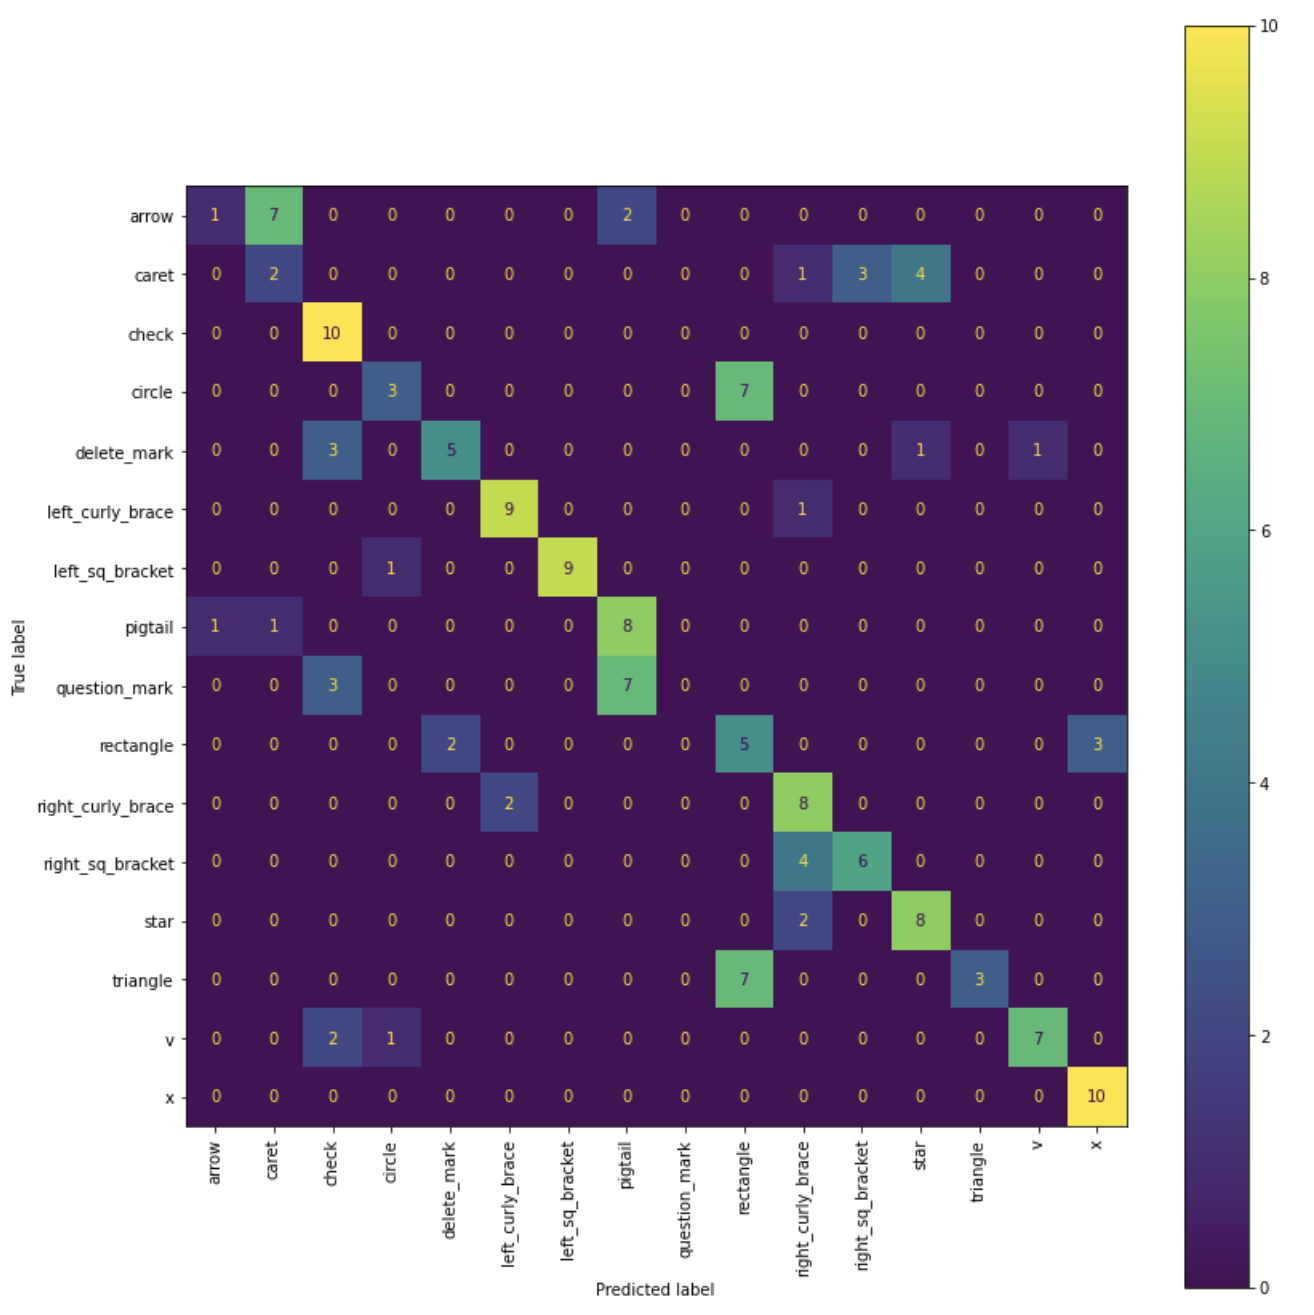

Despite achieving high training accuracy, the LSTM-64 confusion matrix reveals a decline in generalization performance. The model frequently misclassifies several gesture categories, including arrow, circle, triangle, and right_sq_bracket.

In particular, strong confusion is observed between arrow and caret, triangle and rectangle, and question_mark and pigtail. The increased number of parameters appears to cause overfitting, resulting in reduced robustness on unseen test samples.

## Evaluate $1 Recognizer

In [52]:
import time
from recognizer import DollarRecognizer, Point
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dollar = DollarRecognizer()

templates_per_class = 10
template_counts = {}

# Add templates from training set
for sequence, label in zip(X_train, y_train):
    class_id = np.argmax(label)
    class_name = encoder.inverse_transform([class_id])[0]

    if template_counts.get(class_name, 0) >= templates_per_class:
        continue

    points = [Point(float(x), float(y)) for x, y in sequence]

    dollar.add_template(class_name, points)
    template_counts[class_name] = template_counts.get(class_name, 0) + 1

print("Templates used per class:")
print(template_counts)

# Evaluate on test set
y_true_dollar = []
y_pred_dollar = []
recognition_times = []

for sequence, label in zip(X_test, y_test):

    true_class_id = np.argmax(label)
    true_label = encoder.inverse_transform([true_class_id])[0]

    points = [Point(float(x), float(y)) for x, y in sequence]

    start = time.perf_counter()
    result = dollar.recognize(points)
    end = time.perf_counter()

    recognition_times.append(end - start)

    if isinstance(result, tuple):
        predicted_label = result[0]
    else:
        predicted_label = result

    y_true_dollar.append(true_label)
    y_pred_dollar.append(predicted_label)

dollar_accuracy = np.mean(
    np.array(y_true_dollar) == np.array(y_pred_dollar)
)

total_prediction_time = np.sum(recognition_times)
avg_prediction_time_ms = np.mean(recognition_times) * 1000

print(f"$1 Recognizer Accuracy: {dollar_accuracy:.4f}")
print(f"Total prediction time: {total_prediction_time:.4f} seconds")
print(f"Average time per gesture: {avg_prediction_time_ms:.2f} ms")

Templates used per class:
{'delete_mark': 10, 'caret': 10, 'left_curly_brace': 10, 'left_sq_bracket': 10, 'v': 10, 'right_curly_brace': 10, 'star': 10, 'triangle': 10, 'arrow': 10, 'rectangle': 10, 'x': 10, 'right_sq_bracket': 10, 'circle': 10, 'question_mark': 10, 'pigtail': 10, 'check': 10}
$1 Recognizer Accuracy: 0.6188
Total prediction time: 19.2698 seconds
Average time per gesture: 120.44 ms


The reported prediction time includes the complete evaluation loop and Python execution overhead. Therefore, the measured latency reflects practical runtime performance rather than pure algorithmic inference time.

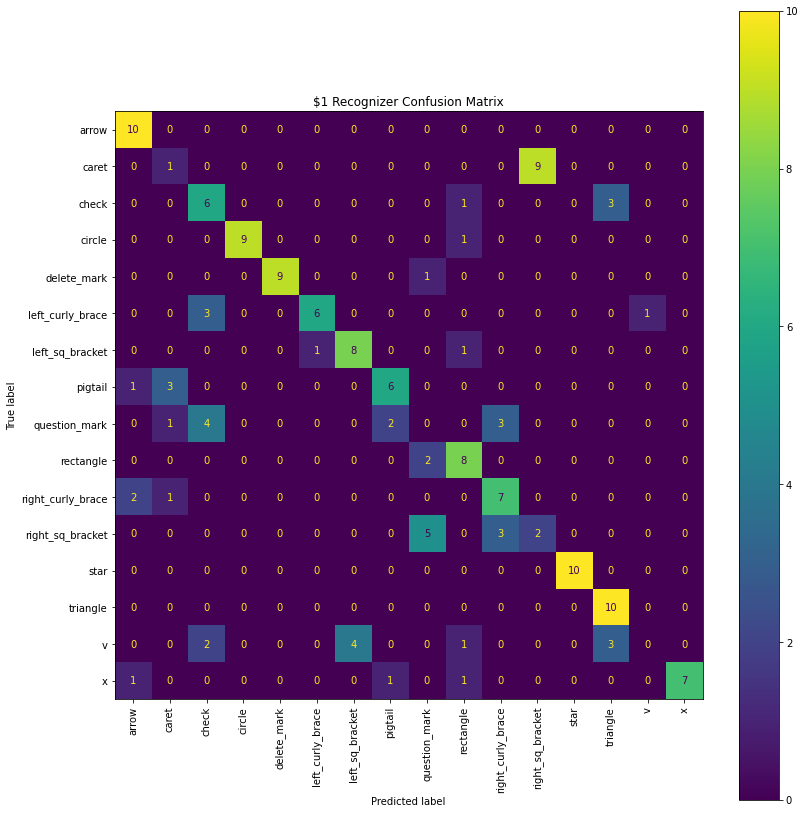

In [53]:
# Show confusion matrix for $1 recognizer

cm = confusion_matrix(
    y_true_dollar,
    y_pred_dollar,
    labels=encoder.classes_
)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical"
)

plt.title("$1 Recognizer Confusion Matrix")
plt.tight_layout()
plt.show()

The $1 Recognizer confusion matrix reveals strong performance for gestures with distinctive geometric shapes, such as arrow, star, and triangle, which achieve perfect classification accuracy.

However, the recognizer struggles with gestures that contain similar stroke sequences or local shape patterns. Significant confusion can be observed between caret and right_sq_bracket, question_mark and check, as well as right_sq_bracket and question_mark.

Unlike the LSTM models, the $1 Recognizer relies on template matching and does not learn discriminative features from the training data. Consequently, it is more sensitive to variations in drawing style, stroke order, and starting position.

Overall, the $1 Recognizer provides competitive results for simple and consistent gestures while requiring no training phase, but its performance decreases for complex or visually similar gesture classes.

In [54]:
# show results table
import pandas as pd

results = pd.DataFrame({
    "Method": ["LSTM-64", "LSTM-32", "LSTM-16", "$1"],
    "Trainable parameters": [19760, 5280, 1496, "N/A"],
    "Accuracy (%)": [58.75, 73.75, 70.00, 61.88],
    "Total prediction time (s)": [0.2986, 0.2778, 0.3078, 19.2698],
    "Time per gesture (ms)": [
        0.2986 / 160 * 1000,
        0.2778 / 160 * 1000,
        0.3078 / 160 * 1000,
        19.2698 / 160 * 1000
    ]
})

results["Time per gesture (ms)"] = results[
    "Time per gesture (ms)"
].round(2)

results

,Method,Trainable parameters,Accuracy (%),Total prediction time (s),Time per gesture (ms)
0,LSTM-64,19760,58.75,0.2986,1.87
1,LSTM-32,5280,73.75,0.2778,1.74
2,LSTM-16,1496,70.00,0.3078,1.92
3,$1,N/A,61.88,19.2698,120.44


# Discussion
This project compared multiple LSTM architectures with the classical $1 Recognizer for unistroke gesture recognition using the gesture logs provided by Wobbrock et al. The original dataset was used exclusively for training, while a custom test set containing ten user-generated samples for each of the sixteen gesture classes was collected using a dedicated gesture capture tool.

The learning curves show that all LSTM models learned meaningful gesture representations within only a few epochs. Training accuracy increased rapidly while training loss decreased consistently, indicating successful optimization. Validation accuracy improved during the initial epochs and then stabilized, whereas validation loss fluctuated after the first few epochs, suggesting limited generalization to unseen user data.

Among the evaluated architectures, the LSTM-32 model achieved the highest test accuracy of 73.75%, outperforming both the smaller LSTM-16 model (70.00%) and the larger LSTM-64 model (58.75%). These results indicate that increasing model complexity does not necessarily improve performance. The LSTM-64 model likely overfitted the training data due to its larger number of trainable parameters, while the LSTM-16 model may have had insufficient capacity to capture the full variability of the gesture classes. Consequently, the intermediate architecture provided the best balance between model complexity and generalization ability.

The confusion matrices reveal that geometrically distinctive gestures, such as caret, left_curly_brace, left_sq_bracket, right_curly_brace, star, and x, were recognized reliably across all LSTM configurations. In contrast, gestures with similar trajectories or local geometric features caused frequent misclassifications. Common examples include confusion between question_mark and pigtail, triangle and rectangle, and v and check. These findings suggest that visually similar stroke patterns remain challenging even for learned sequence models.

The $1 Recognizer achieved an accuracy of 61.88%, which is lower than the LSTM-16 and LSTM-32 models but higher than the overfitted LSTM-64 model. The confusion matrix indicates that the template-based approach struggles particularly with gestures that share similar shapes or vary in stroke order and drawing style.

A major difference between both approaches can be observed in their computational characteristics. The $1 Recognizer requires no training phase and can be deployed immediately after defining templates. However, its prediction time increases linearly with the number of stored templates because each input gesture must be compared against all reference examples. In this experiment, the average prediction time was approximately 120 ms per gesture. In contrast, the trained LSTM models required an initial training phase but achieved significantly faster inference times of approximately 2 ms per gesture due to optimized matrix operations.

For a practical application, the LSTM-32 model would be the preferred choice. It achieved the highest recognition accuracy while maintaining very low inference latency and requiring substantially fewer trainable parameters than the LSTM-64 model. Although the LSTM-16 model provided comparable computational efficiency, its lower accuracy makes it a less attractive option. The $1 Recognizer remains valuable for rapid prototyping scenarios or applications with limited training data, but its lower robustness to user-specific drawing styles and significantly higher prediction time make it less suitable for real-time gesture recognition systems with larger gesture vocabularies.

Overall, the results demonstrate that moderately sized recurrent neural networks provide the best trade-off between recognition performance, computational efficiency, and scalability for unistroke gesture recognition.

Several limitations should be considered. The evaluation was based on a relatively small custom test set containing ten samples per gesture class and involved only a single user. Future work could investigate larger multi-user datasets, data augmentation techniques, bidirectional LSTM architectures, or transformer-based sequence models to improve robustness and generalization performance.